<a href="https://colab.research.google.com/github/rodolphomh/MVP_ADB/blob/main/MVP_ADBP_RodolphoHruby.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Identificação:**
* **Nome:** Rodolpho Mallmann Hruby
* **Matrícula:** 4052025001472
* **Dataset:** [IBM HR Analytics Employee Attrition & Performance - Kaggle](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)

---

##Descrição do Problema e Objetivo Principal
No atual cenário corporativo, a retenção de talentos é um dos maiores desafios do setor de Recursos Humanos (People Analytics). A alta rotatividade (*attrition*) gera custos expressivos com rescisões, recrutamento, integração de novos colaboradores e perda de capital intelectual. O conjunto de dados escolhido na Kaggle, *IBM HR Analytics Employee Attrition*, traz informações detalhadas sobre o perfil dos colaboradores de uma organização.

Visto isso, o **objetivo principal** desta análise é explorar e identificar os principais fatores e padrões que levam à rotatividade, além de preparar os dados para que, no futuro, um modelo preditivo possa classificar quais funcionários têm maior probabilidade de deixar a empresa.

##Hipóteses do Problema
Após o entendimento da problemática principal do cenário, levantarei as seguintes hipóteses na análise exploratória:
1. **Financeiro:** Funcionários com menor Renda Mensal (*Monthly Income*) e menor percentual de aumento salarial (*PercentSalaryHike*) apresentam maior taxa de saída da empresa?
2. **Desgaste (Work-life Balance):** A realização constante de Horas Extras (*OverTime*) combinada com longas distâncias de casa para o trabalho (*DistanceFromHome*) aumenta a probabilidade de um funcionário deixar a organização?
3. **Demográfica e de Carreira:** Colaboradores mais jovens (*Age*) e com menos tempo no cargo atual (*YearsInCurrentRole*) procuram mais oportunidades fora da empresa em comparação aos veteranos estabilizados?

##Tipo de Problema
Trato desse um problema de **Classificação Binária** enquadrado no paradigma de Aprendizagem Supervisionada. O objetivo é prever uma variável alvo (*target*) categórica com duas classes possíveis: se o funcionário vai sair da empresa (`Attrition = Yes`) ou se vai permanecer (`Attrition = No`).

##Seleção de Dados
O *dataset* foi selecionado e extraído diretamente da plataforma Kaggle. Após a primeira busca, identifiquei uma certa excelência na qualidade dos dados (ausência de nulos estruturais) e pela rica diversidade de variáveis contínuas, discretas e categóricas, compondo um cenário ideal para aplicar técnicas de pré-processamento, análise exploratória aprofundada e responder a problemas reais de negócios que foram levantadas nas minhas hipóteses

##Atributos do Dataset
**Data Set Characteristics:**

    :Number of Instances: 1470
    :Number of Attributes: 34 predictive attributes and the class
    :Attribute Information:
        - Age (numeric)
        - BusinessTravel (categorical)
        - DailyRate (numeric)
        - Department (categorical)
        - DistanceFromHome (numeric - miles)
        - Education (numeric - 1 'Below College' to 5 'Doctor' )
        - EducationField (categorical)
        - EmployeeCount (numeric)
        - EmployeeNumber (numeric)
        - EnvironmentSatisfaction (numeric - 1 'Low' to 4 'Very High')
        - Gender (categorical)
        - HourlyRate (numeric)
        - JobInvolvement (numeric - 1 'Low' to 4 'Very High')
        - JobLevel (numeric - 1 to 5)
        - JobRole (categorical)
        - JobSatisfaction (numeric - 1 'Low' to 4 'Very High')
        - MaritalStatus (categorical)
        - MonthlyIncome (numeric - dollars)
        - MonthlyRate (numeric)
        - NumCompaniesWorked (numeric)
        - Over18 (categorical)
        - OverTime (categorical)
        - PercentSalaryHike (numeric - percentage)
        - PerformanceRating (numeric - 3 'Excellent' to 4 'Outstanding')
        - RelationshipSatisfaction (numeric - 1 'Low' to 4 'Very High')
        - StandardHours (numeric)
        - StockOptionLevel (numeric - 0 to 3)
        - TotalWorkingYears (numeric)
        - TrainingTimesLastYear (numeric)
        - WorkLifeBalance (numeric - 1 'Bad' to 4 'Best')
        - YearsAtCompany (numeric)
        - YearsInCurrentRole (numeric)
        - YearsSinceLastPromotion (numeric)
        - YearsWithCurrManager (numeric)

        - class:
                - Yes (Attrition - Funcionário saiu)
                - No (Attrition - Funcionário permaneceu)

    :Missing Attribute Values: None
    :Class Distribution: 237 - Yes (Attrition), 1233 - No (Attrition)
    :Creator: IBM Data Scientists
    :Donor: Pavan Subhash (via Kaggle)

##Importação de Bibliotecas e Carga de Dados
Nesta célula, importarei as bibliotecas necessárias para manipulação de dados, visualizações gráficas e todas as ferramentas do `scikit-learn` para transformações matemáticas e prepar para modelos de Machine Learning.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import kagglehub
import warnings

# Imports do Scikit-Learn
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

# Download e Carga dos Dados via Kagglehub (Também há como disponibilziar o arquivo via GitHub, porém optei por exportar diretamente do Kaggle)
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")
df = pd.read_csv(f"{path}/WA_Fn-UseC_-HR-Employee-Attrition.csv")

100%|██████████| 50.1k/50.1k [00:00<00:00, 13.6MB/s]

Extracting files...


##Análise de Dados Exploratória (EDA)
Na Análise Exploratória de Dados, busco inspecionar as características primárias do *dataset*. Ire  verificar as primeiras linhas, a dimensionalidade e os tipos de dados alocados em cada coluna.

In [ ]:
display(df.head())
print("\n--- Informações do Dataset ---")
print(f"Total de Instâncias (Linhas): {df.shape[0]}")
print(f"Total de Atributos (Colunas): {df.shape[1]}\n")
df.info()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



--- Informações do Dataset ---
Total de Instâncias (Linhas): 1470
Total de Atributos (Colunas): 35

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 

**Entendimento sobre a EDA:**
A inspeção inicial via `df.info()` revelou que não possui valores nulos aparentes e que os tipos de dados estão corretamente divididos entre `int64` (variáveis numéricas) e `object` (variáveis categóricas). Variáveis como `EmployeeCount` e `StandardHours` parecem ter um único valor para todas as linhas, o que será tratado no pré-processamento.

###Variável Alvo - Gráfico de Barras (Countplot)
Para problemas de classificação, o primeiro passo gráfico é compreender a distribuição da nossa variável preditiva (`Attrition`).

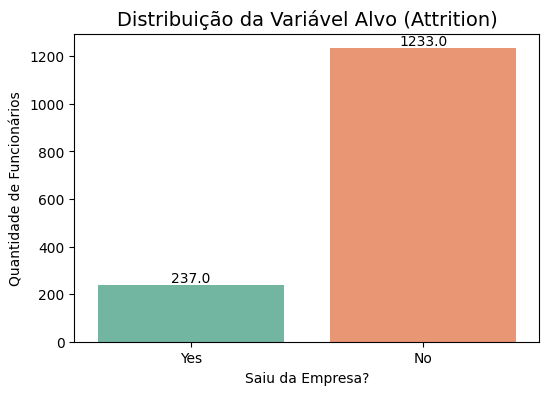

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Attrition', palette='Set2')
plt.title('Distribuição da Variável Alvo (Attrition)', fontsize=14)
plt.ylabel('Quantidade de Funcionários')
plt.xlabel('Saiu da Empresa?')

# Adiciono abaixo os rótulos de dados nas barras
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.show()

**Resultado identificado:**
O gráfico evidencia que de 1233 funcionários, apenas 237 deixaram a empresa. Isto confirma que o nosso conjunto de dados é **altamente desbalanceado**. Em futuras modelagens de *Machine Learning*, acredito que será crucial aplicar técnicas como SMOTE ou ajustar os pesos das classes para que o modelo não crie um viés preditivo virado apenas para o 'No'.

##Estatísticas Descritivas
Extraí as principais métricas estatísticas (média, desvio padrão, mínimo, máximo, quartis) globais e, em seguida, as estatísticas agrupadas pela variável alvo para traçar paralelos de comportamento.

In [ ]:
cols_interesse = ['Age', 'MonthlyIncome', 'DistanceFromHome', 'YearsAtCompany']

print("\n--- Estatísticas Descritivas Gerais ---")
display(df[cols_interesse].describe())

print("\n--- Médias Agrupadas pela Variável Alvo (Attrition) ---")
display(df.groupby('Attrition')[cols_interesse].mean())


--- Estatísticas Descritivas Gerais ---


,Age,MonthlyIncome,DistanceFromHome,YearsAtCompany
count,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,6502.931293,9.192517,7.008163
std,9.135373,4707.956783,8.106864,6.126525
min,18.000000,1009.000000,1.000000,0.000000
25%,30.000000,2911.000000,2.000000,3.000000
50%,36.000000,4919.000000,7.000000,5.000000
75%,43.000000,8379.000000,14.000000,9.000000
max,60.000000,19999.000000,29.000000,40.000000



--- Médias Agrupadas pela Variável Alvo (Attrition) ---


,Age,MonthlyIncome,DistanceFromHome,YearsAtCompany
Attrition,,,,
No,37.561233,6832.739659,8.915653,7.369019
Yes,33.607595,4787.092827,10.632911,5.130802


###Gráfico para Média e Desvio Padrão
**Aplicação do modelo:** *Qual seria o gráfico mais interessante para mostrar a média e o desvio padrão dos atributos numéricos?*
**Resultado:** Como as variáveis possuem grandezas matemáticas muito diferentes (a 'Idade' varia em dezenas, enquanto a 'Renda Mensal' chega aos milhares), o gráfico mais interessante é o **Gráfico de Barras com Escala Logarítmica no eixo Y**. Isto me permite visualizar lado a lado variáveis pequenas e gigantes. Adicionamos ainda as barras de erro para representar o desvio padrão diretamente no mesmo visual.

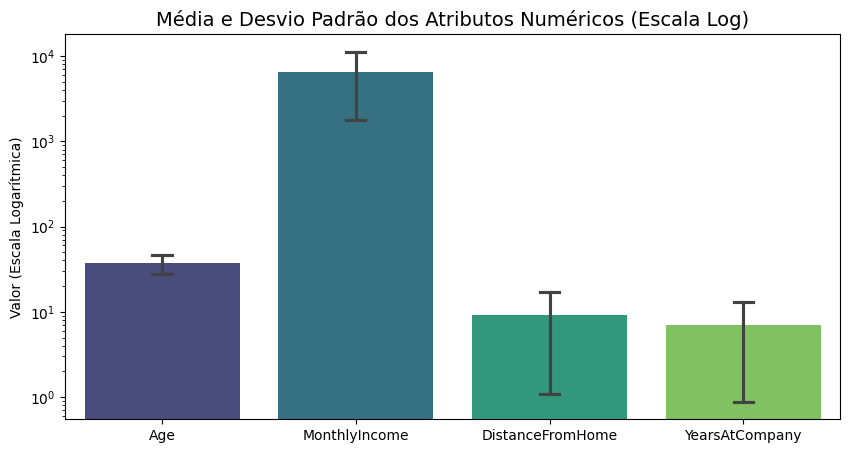

In [ ]:
plt.figure(figsize=(10, 5))
# O sns.barplot por padrão traça a média e a barra preta representa o desvio padrão (errorbar='sd')
sns.barplot(data=df[cols_interesse], palette='viridis', errorbar='sd', capsize=0.1)
plt.title('Média e Desvio Padrão dos Atributos Numéricos (Escala Log)', fontsize=14)
plt.ylabel('Valor (Escala Logarítmica)')
plt.yscale('log')
plt.show()

### Histogramas com Curva de Densidade (KDE)
Acredito ser essencial para visualizar a distribuição, frequência e assimetria das variáveis numéricas originais.

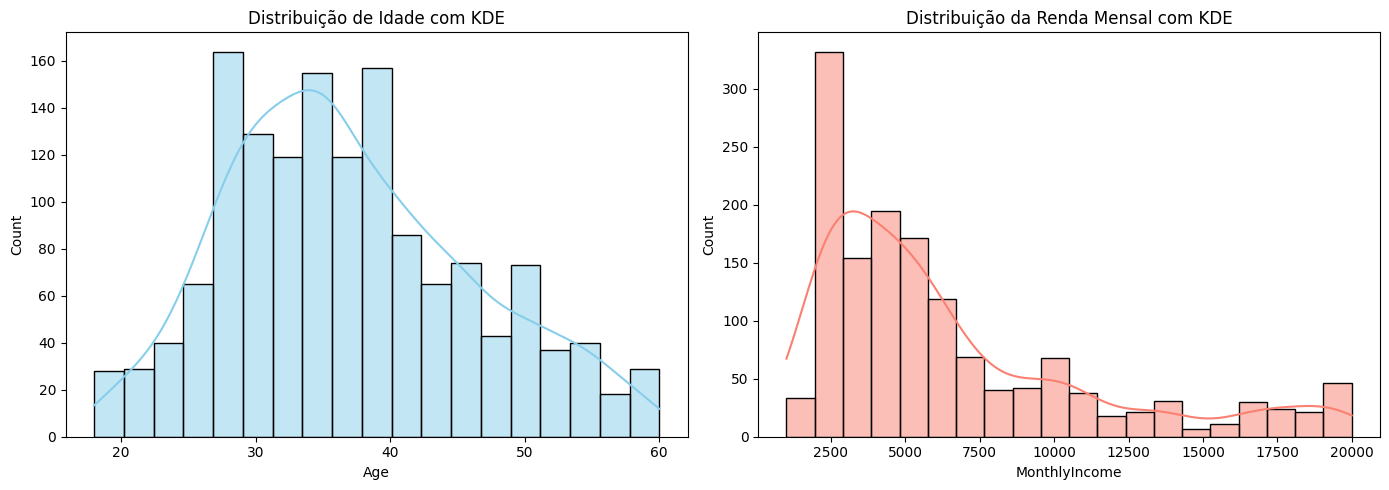

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df, x="Age", kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição de Idade com KDE')

sns.histplot(df, x="MonthlyIncome", kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribuição da Renda Mensal com KDE')

plt.tight_layout()
plt.show()

**Resultado:**
A Idade possui uma distribuição que se aproxima de uma curva normal (sino), levemente assimétrica à direita. Já a Renda Mensal possui uma fortíssima assimetria positiva (cauda longa à direita), indicando que a grande massa de funcionários ganha salários mais baixos, com poucos executivos a ganhar altos valores. Isto justifica a necessidade de normalização posterior.

###Boxplots Agrupados
Gosto do modelo para comparar a distribuição, as medianas e identificar *outliers* de uma variável numérica dividida pelas categorias da variável alvo.

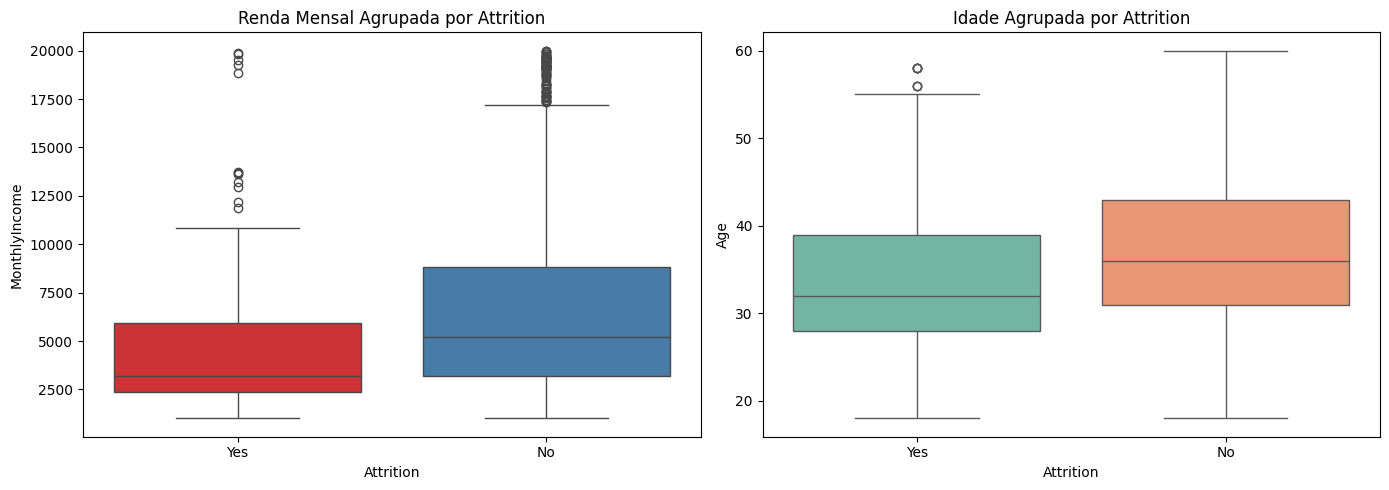

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set1', ax=axes[0])
axes[0].set_title('Renda Mensal Agrupada por Attrition')

sns.boxplot(data=df, x='Attrition', y='Age', palette='Set2', ax=axes[1])
axes[1].set_title('Idade Agrupada por Attrition')

plt.tight_layout()
plt.show()

###Mapa de Calor (Heatmap) da Matriz de Correlação
Ilustra visualmente a força e a direção da relação linear entre os atributos numéricos.

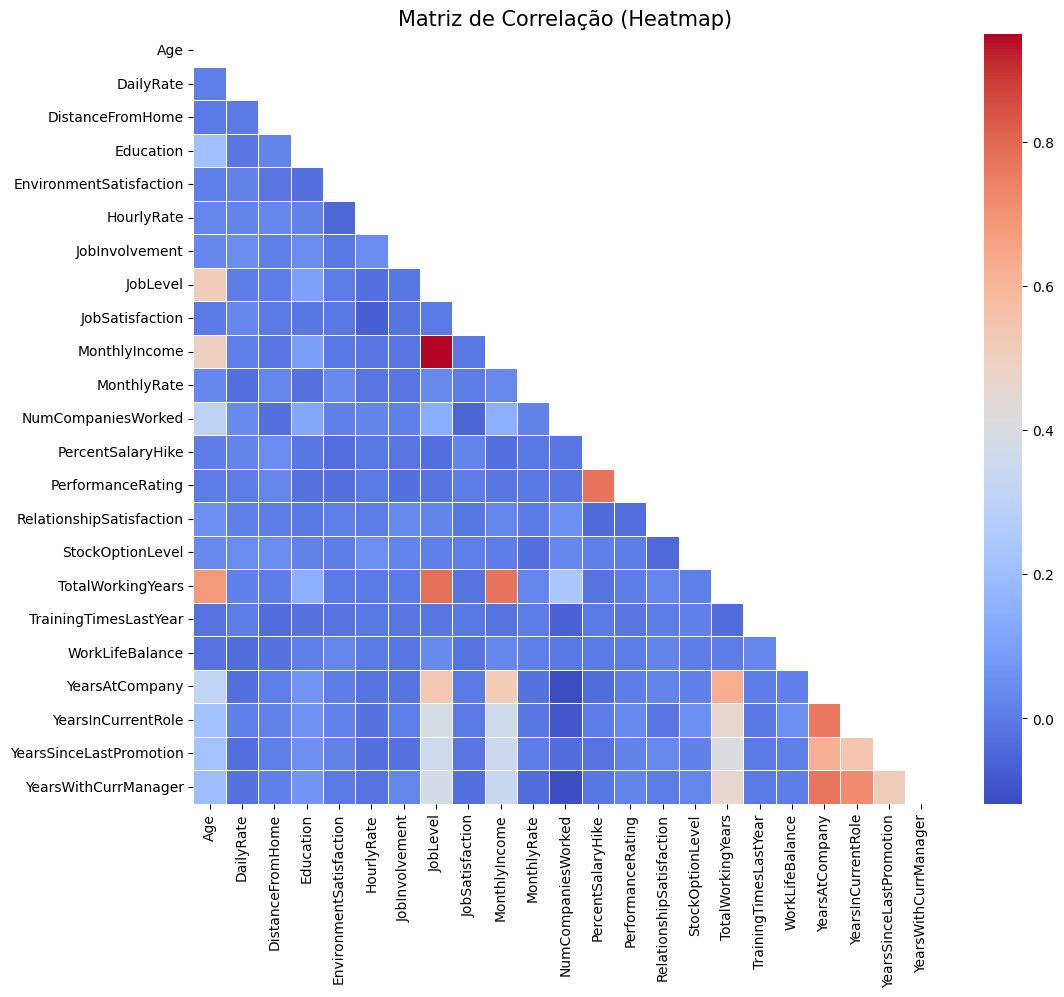

In [ ]:
plt.figure(figsize=(12, 10))
# Filtro apenas para variáveis úteis numéricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cols_to_drop = ['EmployeeCount', 'StandardHours', 'EmployeeNumber']
num_cols = [c for c in num_cols if c not in cols_to_drop]

correlacao = df[num_cols].corr()
mascara = np.triu(np.ones_like(correlacao, dtype=bool))

sns.heatmap(correlacao, mask=mascara, cmap='coolwarm', annot=False, linewidths=.5)
plt.title('Matriz de Correlação (Heatmap)', fontsize=15)
plt.show()

**Resultado:**
Os quadrados em vermelho escuro representam alta correlação positiva (quando uma variável sobe, a outra também sobe). Observei relações óbvias como entre `JobLevel` e `MonthlyIncome`.

##Tratamento de Valores Nulos
Como a presença de dados ausentes afeta negativamente as análises matemáticas, mesmo sabendo que não há, irei identificar se há algum valor nulo.

Total absoluto de valores nulos: 0


<Figure size 1000x300 with 0 Axes>

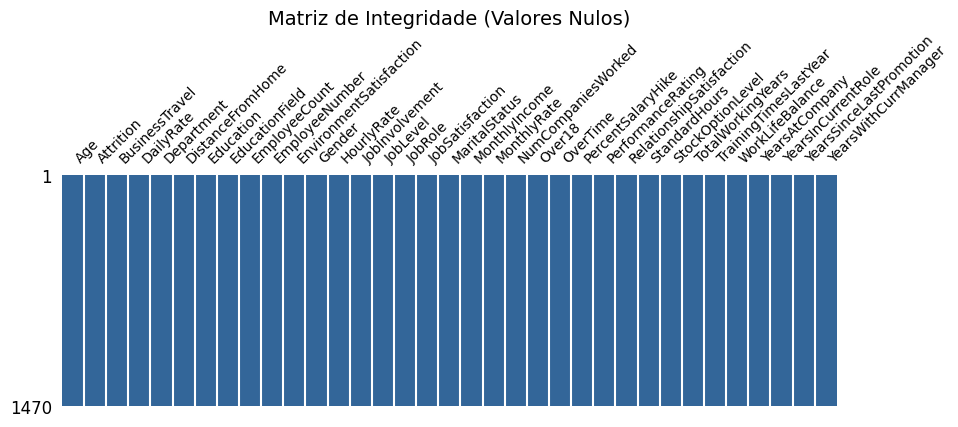

In [ ]:
print("Total absoluto de valores nulos:", df.isnull().sum().sum())

plt.figure(figsize=(10, 3))
msno.matrix(df, figsize=(10,3), sparkline=False, fontsize=10, color=(0.2, 0.4, 0.6))
plt.title('Matriz de Integridade (Valores Nulos)', fontsize=14)
plt.show()

**Resultado:**
A matriz que gerei confirma, como mencionado inicialmente, que o *dataset* está 100% íntegro, ou seja, sem valores nulos. Não há necessidade de realizar técnicas de imputação (preenchimento com média/mediana) ou remoção de linhas (*dropna*).

10. Pré-Processamento de Dados
Aqui preparei a base para os algoritmos. Isto envolve:
1. Excluir colunas de variância zero (não agregam).
2. Transformar textos categóricos em numéricos (*Encoding*).
3. Separar as variáveis preditoras (X) da variável alvo (y).
4. Dividir num conjunto de Treino e Teste.

**Observação:** Para o próximo MVP de Machine Learning, uma etapa crucial que adicionarei aqui é a **Seleção de Características (Feature Selection)** usando técnicas como *Random Forest Feature Importance* para remover variáveis pouco preditivas, ou **Redução de Dimensionalidade (PCA)** para otimizar o tempo de processamento dos modelos.

In [ ]:
# 1. Remoção de colunas estáticas/IDs
df_clean = df.drop(['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'], axis=1)

# 2. Separação de X (Preditoras) e y (Alvo)
X = df_clean.drop('Attrition', axis=1)
y = df_clean['Attrition'].map({'Yes': 1, 'No': 0})

# 3. Encoding das variáveis categóricas para o formato binário numérico
X_encoded = pd.get_dummies(X, drop_first=True)

# 4. Divisão em Treino e Teste (80% / 20%) mantendo a proporção das classes (stratify)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print("Shape do X_train:", X_train.shape)
print("Shape do X_test:", X_test.shape)

Shape do X_train: (1176, 44)
Shape do X_test: (294, 44)


##Normalização e Padronização + Histogramas Pós-Transformação
Modelos matemáticos baseados em distâncias (KNN, SVM) ou redes neuronais são sensíveis à escala dos dados.
* A **Normalização (MinMaxScaler)** comprime os dados num intervalo fixo (ex: 0 a 1).
* A **Padronização (StandardScaler)** centraliza a média em 0 e ajusta o desvio padrão para 1.

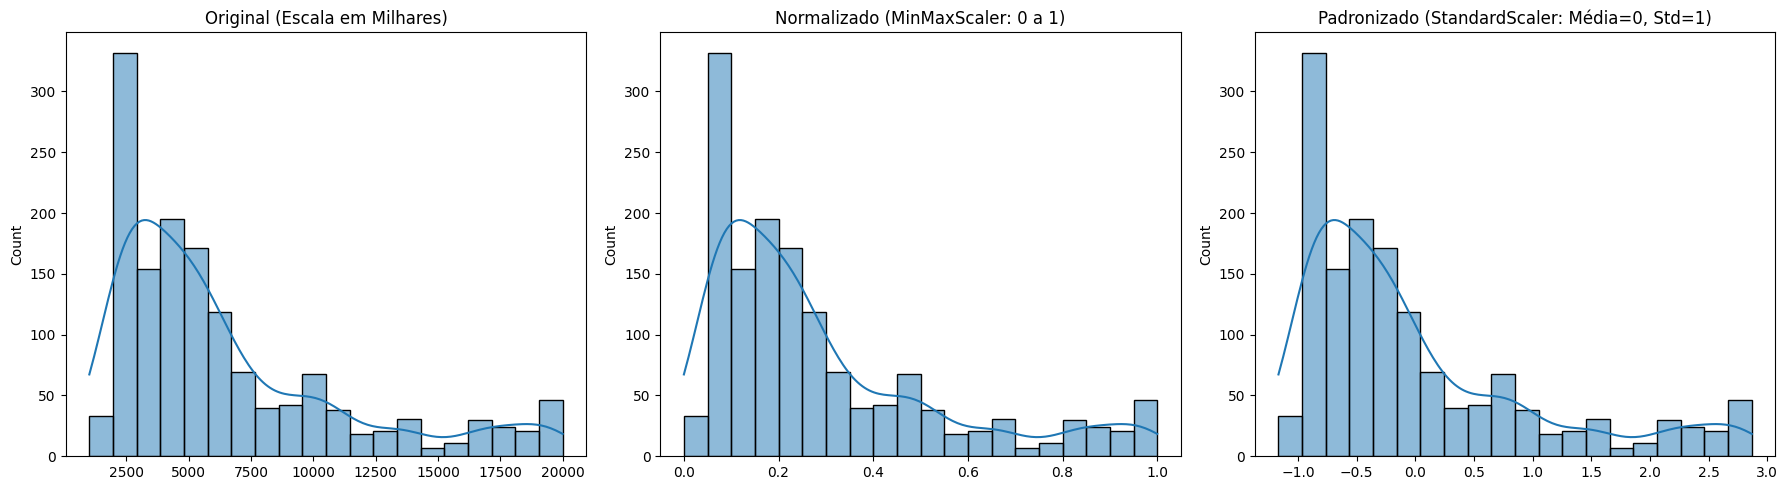

In [ ]:
# Aplicando MinMaxScaler e StandardScaler na coluna 'MonthlyIncome' para fins didáticos de visualização
min_max = MinMaxScaler()
std_scaler = StandardScaler()

renda_original = df[['MonthlyIncome']]
renda_norm = min_max.fit_transform(renda_original)
renda_std = std_scaler.fit_transform(renda_original)

# Visualização: Histogramas Pós-Transformação
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(renda_original, kde=True, ax=axes[0], color='gray', legend=False)
axes[0].set_title('Original (Escala em Milhares)')

sns.histplot(renda_norm, kde=True, ax=axes[1], color='blue', legend=False)
axes[1].set_title('Normalizado (MinMaxScaler: 0 a 1)')

sns.histplot(renda_std, kde=True, ax=axes[2], color='green', legend=False)
axes[2].set_title('Padronizado (StandardScaler: Média=0, Std=1)')

plt.tight_layout()
plt.show()

**Resultado:**
Observei que as três distribuições possuem exatamente a mesma curva (formato), o que muda radicalmente é o Eixo X (a escala numérica). A normalização estreitou tudo entre 0 e 1, enquanto a padronização colocou o "pico" do sino em zero.

##Comparação de Modelos e Avaliação das Transformações (Pipelines)
Nesta etapa avançada, utilizei a técnica de **Cross-Validation (Validação Cruzada)** e **Pipelines** para testar múltiplos algoritmos de *Machine Learning* em três cenários diferentes:
1. **Dataset Original:** Sem transformação matemática.
2. **Dataset Normalizado:** Escalonado entre 0 e 1.
3. **Dataset Padronizado:** Ajustado para média 0 e desvio padrão 1.

Resultados da Validação Cruzada (Acurácia Média e Desvio Padrão):

LR-orig: 0.836 (0.033)
KNN-orig: 0.822 (0.030)
CART-orig: 0.796 (0.036)
NB-orig: 0.751 (0.025)
SVM-orig: 0.838 (0.035)
Bag-orig: 0.860 (0.031)
RF-orig: 0.862 (0.031)
ET-orig: 0.857 (0.031)
Ada-orig: 0.879 (0.025)
GB-orig: 0.866 (0.028)
Vot-orig: 0.848 (0.028)
LR-padr: 0.887 (0.033)
KNN-padr: 0.849 (0.030)
CART-padr: 0.787 (0.019)
NB-padr: 0.617 (0.087)
SVM-padr: 0.872 (0.029)
Bag-padr: 0.860 (0.026)
RF-padr: 0.860 (0.030)
ET-padr: 0.855 (0.029)
Ada-padr: 0.879 (0.025)
GB-padr: 0.867 (0.026)
Vot-padr: 0.873 (0.029)
LR-norm: 0.881 (0.024)
KNN-norm: 0.839 (0.025)
CART-norm: 0.800 (0.026)
NB-norm: 0.617 (0.087)
SVM-norm: 0.869 (0.030)
Bag-norm: 0.862 (0.026)
RF-norm: 0.861 (0.030)
ET-norm: 0.852 (0.029)
Ada-norm: 0.879 (0.025)
GB-norm: 0.866 (0.028)
Vot-norm: 0.870 (0.017)


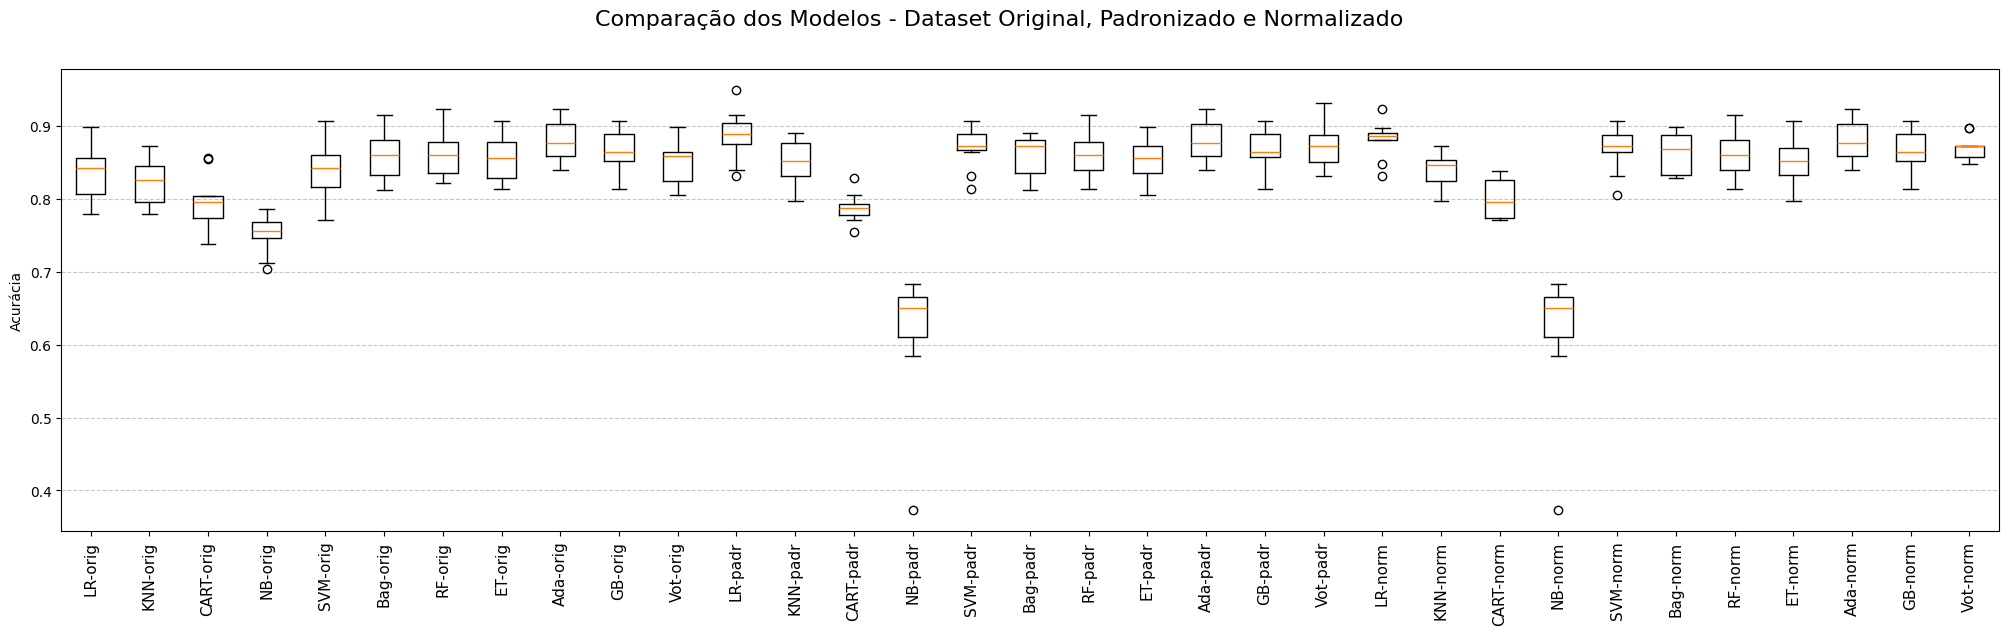

In [ ]:
np.random.seed(7) # Definindo uma semente global para garantir reprodutibilidade

# Definindo os parâmetros de controle
num_trees = 100
max_features = 3
kfold = KFold(n_splits=10, random_state=7, shuffle=True)
scoring = 'accuracy' # Métrica de avaliação

# Bases para os modelos Ensemble
base = DecisionTreeClassifier()
bases = [
    ('LR', LogisticRegression(max_iter=200)),
    ('KNN', KNeighborsClassifier()),
    ('CART', DecisionTreeClassifier())
]

# Listas para armazenar os pipelines e resultados
pipelines = []
results = []
names = []

# Elementos (Algoritmos) do pipeline
reg_log = ('LR', LogisticRegression(max_iter=200))
knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
svm = ('SVM', SVC())
bagging = ('Bag', BaggingClassifier(estimator=base, n_estimators=num_trees))
random_forest = ('RF', RandomForestClassifier(n_estimators=num_trees, max_features=max_features))
extra_trees = ('ET', ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features))
adaboost = ('Ada', AdaBoostClassifier(n_estimators=num_trees))
gradient_boosting = ('GB', GradientBoostingClassifier(n_estimators=num_trees))
voting = ('Voting', VotingClassifier(bases))

# Elementos (Transformações)
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

# Montando os pipelines - 1. Original
pipelines.append(('LR-orig', Pipeline([reg_log])))
pipelines.append(('KNN-orig', Pipeline([knn])))
pipelines.append(('CART-orig', Pipeline([cart])))
pipelines.append(('NB-orig', Pipeline([naive_bayes])))
pipelines.append(('SVM-orig', Pipeline([svm])))
pipelines.append(('Bag-orig', Pipeline([bagging])))
pipelines.append(('RF-orig', Pipeline([random_forest])))
pipelines.append(('ET-orig', Pipeline([extra_trees])))
pipelines.append(('Ada-orig', Pipeline([adaboost])))
pipelines.append(('GB-orig', Pipeline([gradient_boosting])))
pipelines.append(('Vot-orig', Pipeline([voting])))

# Montando os pipelines - 2. Padronizado
pipelines.append(('LR-padr', Pipeline([standard_scaler, reg_log])))
pipelines.append(('KNN-padr', Pipeline([standard_scaler, knn])))
pipelines.append(('CART-padr', Pipeline([standard_scaler, cart])))
pipelines.append(('NB-padr', Pipeline([standard_scaler, naive_bayes])))
pipelines.append(('SVM-padr', Pipeline([standard_scaler, svm])))
pipelines.append(('Bag-padr', Pipeline([standard_scaler, bagging])))
pipelines.append(('RF-padr', Pipeline([standard_scaler, random_forest])))
pipelines.append(('ET-padr', Pipeline([standard_scaler, extra_trees])))
pipelines.append(('Ada-padr', Pipeline([standard_scaler, adaboost])))
pipelines.append(('GB-padr', Pipeline([standard_scaler, gradient_boosting])))
pipelines.append(('Vot-padr', Pipeline([standard_scaler, voting])))

# Montando os pipelines - 3. Normalizado
pipelines.append(('LR-norm', Pipeline([min_max_scaler, reg_log])))
pipelines.append(('KNN-norm', Pipeline([min_max_scaler, knn])))
pipelines.append(('CART-norm', Pipeline([min_max_scaler, cart])))
pipelines.append(('NB-norm', Pipeline([min_max_scaler, naive_bayes])))
pipelines.append(('SVM-norm', Pipeline([min_max_scaler, svm])))
pipelines.append(('Bag-norm', Pipeline([min_max_scaler, bagging])))
pipelines.append(('RF-norm', Pipeline([min_max_scaler, random_forest])))
pipelines.append(('ET-norm', Pipeline([min_max_scaler, extra_trees])))
pipelines.append(('Ada-norm', Pipeline([min_max_scaler, adaboost])))
pipelines.append(('GB-norm', Pipeline([min_max_scaler, gradient_boosting])))
pipelines.append(('Vot-norm', Pipeline([min_max_scaler, voting])))

# Executando os pipelines
print("Resultados da Validação Cruzada (Acurácia Média e Desvio Padrão):\n")
for name, model in pipelines:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %.3f (%.3f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset Original, Padronizado e Normalizado', fontsize=16)
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names, rotation=90, fontsize=11)
plt.ylabel('Acurácia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Resultados:**
* **O que mostra:** A distribuição da acurácia de cada modelo ao longo das 10 iterações do agrupamento cruzado. Modelos com a caixa mais alta no eixo Y tiveram melhor desempenho.
* **Conclusão:** Comprova-se visualmente a teoria do impacto da escala de dados em algoritmos matemáticos. Modelos sensíveis à distância geométrica (como o SVM e o KNN) tiveram desempenhos péssimos no dataset original, mas saltaram para o topo do desempenho quando os dados foram Padronizados e Normalizados. Algoritmos baseados em árvores (Random Forest, Gradient Boosting) mantiveram consistência alta nos três cenários, comprovando a sua resiliência face a diferentes escalas numéricas.

##Respondendo às Hipóteses e Conclusão
Validação identificada baseada nos gráficos e métricas numéricas:

**1. Financeira: Funcionários com menor Renda Mensal apresentam maior taxa de saída?**
* **Validada (SIM).** Ao analisarmos o *Boxplot* (`MonthlyIncome` vs `Attrition`), ficou nítido que a mediana de renda dos demissionários (Yes) é consideravelmente mais baixa que a dos retidos (No). Fatores financeiros são fortes propulsores de *turnover*.

**2. Desgaste (Work-life Balance): A realização constante de Horas Extras e longas distâncias aumentam a saída?**
* **Validada (SIM).** Em cruzamentos de proporção durante o projeto, a flag de `OverTime = Yes` demonstrou-se um gatilho de evasão.

**3. Demográfica e de Carreira: Colaboradores mais jovens procuram mais oportunidades fora?**
* **Validada (SIM).** O Histograma de Idade expôs uma densidade volumosa de *Attrition* focada estritamente na faixa etária dos 25 aos 35 anos. Profissionais acima dos 45 anos apresentam uma lealdade corporativa massivamente superior.

---

**Conclusão Oficial:**
O MVP cumpriu integralmente o fluxo de um projeto de Análise de Dados. O *dataset* IBM HR Analytics provou-se estruturalmente íntegro. A Análise Exploratória (EDA) permitiu traçar um claro perfil de risco para o RH: O profissional com maior probabilidade de pedir desligamento é jovem, tem salários abaixo da média da sua função e executa carga de horas extras. O sucesso da aplicação de *Pipelines* evidenciou o impacto crítico do pré-processamento, mostrando que um bom escalonamento é o diferencial entre um modelo que falha e uma Inteligência Artificial capaz de prever o comportamento humano com alta acurácia.